<a href="https://colab.research.google.com/github/salonikaushal05/Image-Clustering/blob/main/Image_clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (20).zip to archive (20) (1).zip


In [9]:
!unzip 'archive (20) (1).zip' -d images_folder

Archive:  archive (20) (1).zip
  inflating: images_folder/photos_no_class/asparagus-g4c4164115_640.jpg  
  inflating: images_folder/photos_no_class/beanie-g4c423e47b_640.jpg  
  inflating: images_folder/photos_no_class/bibimbap-gf29abdbf1_640.jpg  
  inflating: images_folder/photos_no_class/cat-g0052cc4e9_640.jpg  
  inflating: images_folder/photos_no_class/cat-g0fcd844a4_640.jpg  
  inflating: images_folder/photos_no_class/cat-g11b1f4535_640.jpg  
  inflating: images_folder/photos_no_class/cat-g4ae5d18aa_640.jpg  
  inflating: images_folder/photos_no_class/cat-g4fe5d8c20_640.jpg  
  inflating: images_folder/photos_no_class/cat-g6052b543b_640.jpg  
  inflating: images_folder/photos_no_class/cat-ga3a48da6e_640.jpg  
  inflating: images_folder/photos_no_class/cat-gaf654b3a3_640.jpg  
  inflating: images_folder/photos_no_class/cat-gf324dae69_640.jpg  
  inflating: images_folder/photos_no_class/cave-g68bd31d20_640.jpg  
  inflating: images_folder/photos_no_class/champon-g31fa88e14_640.jpg 

Import required libraries

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image

from sklearn.cluster import KMeans

Load Pretrained Model

In [5]:
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Extract Features from images

In [10]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def extract_features(img_path, model):
    img_array = preprocess_image(img_path)
    features = model.predict(img_array)
    return features.flatten()

image_folder = 'images_folder'
img_paths = [os.path.join(dp, f) for dp, _, filenames in os.walk(image_folder) for f in filenames if f.endswith(('.jpg', '.png', '.jpeg'))]

features = []
for img_path in img_paths:
    features.append(extract_features(img_path, model))

features = np.array(features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

## Perform KMeans Clustering

In [12]:
n_clusters = 5  # Placeholder: Please change this to your desired number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(features)
labels = kmeans.labels_

## Visualize Clusters

Displaying 4 images for Cluster 0:


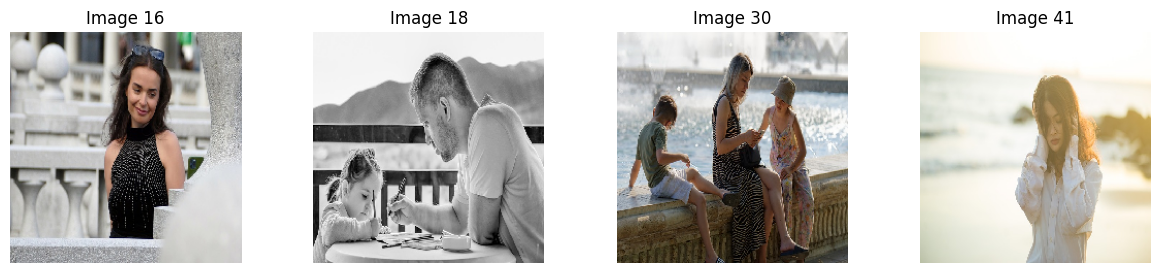

Displaying 5 images for Cluster 1:


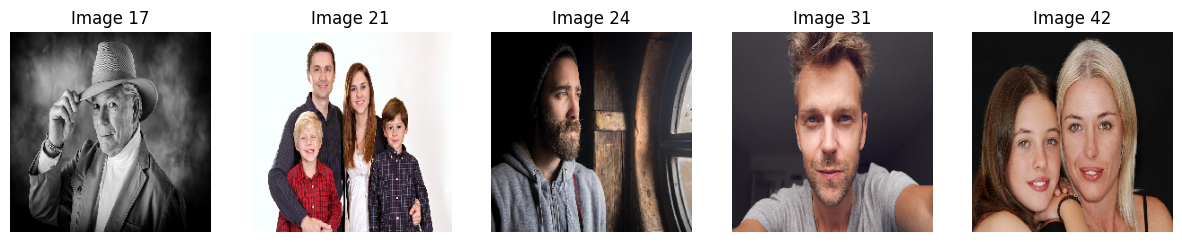

Displaying 5 images for Cluster 2:


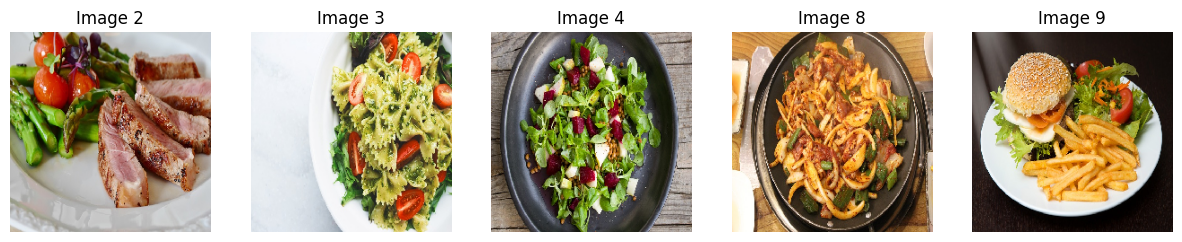

Displaying 5 images for Cluster 3:


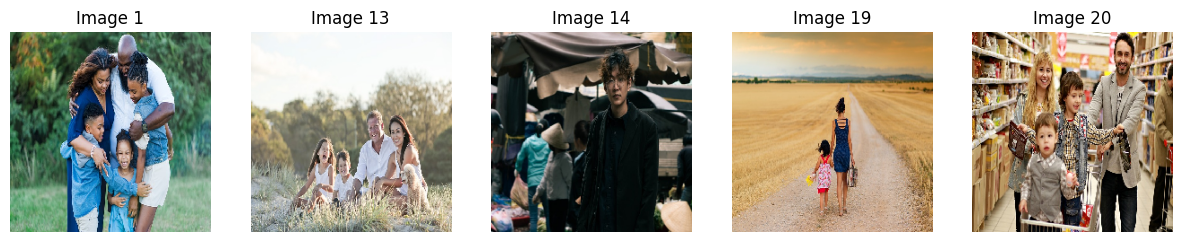

Displaying 5 images for Cluster 4:


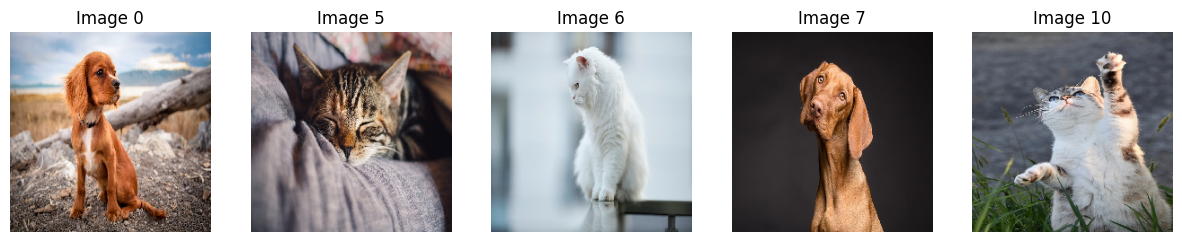

In [13]:
def plot_images_for_cluster(cluster_id, num_images=5):
    cluster_indices = np.where(labels == cluster_id)[0]
    # Ensure we don't try to plot more images than available in the cluster
    num_images_to_plot = min(num_images, len(cluster_indices))

    if num_images_to_plot == 0:
        print(f"No images found for cluster {cluster_id}")
        return

    plt.figure(figsize=(15, 3))
    print(f"Displaying {num_images_to_plot} images for Cluster {cluster_id}:")
    for i in range(num_images_to_plot):
        img_idx = cluster_indices[i]
        img_path = img_paths[img_idx]
        img = image.load_img(img_path, target_size=(224, 224))

        plt.subplot(1, num_images_to_plot, i + 1)
        plt.imshow(img)
        plt.title(f"Image {img_idx}")
        plt.axis('off')
    plt.show()

# Display images for each cluster
for i in range(n_clusters):
    plot_images_for_cluster(i)

## Prediction for a New Image

To 'predict' for a new image in the context of K-Means clustering means to determine which of the existing clusters the new image is most similar to. This is done by extracting features from the new image and then using the trained K-Means model to assign it a cluster label.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
The image 'images_folder/photos_no_class/dog-g0973e56d5_640.jpg' is predicted to belong to Cluster 4
Visualizing the example image and some images from Cluster 4:


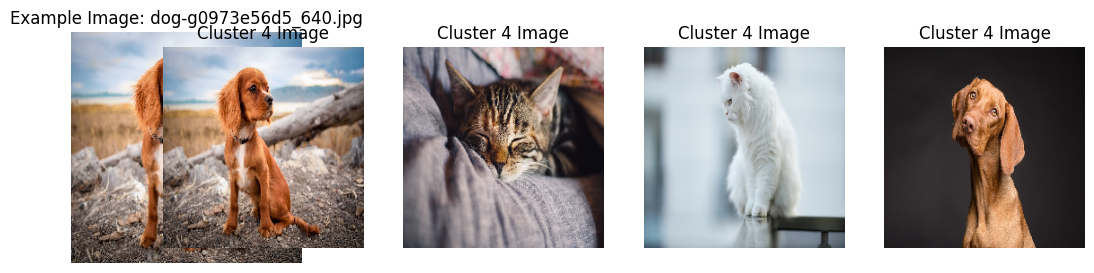

In [14]:
def predict_cluster_for_new_image(new_img_path, model, kmeans_model):
    # Extract features for the new image
    new_features = extract_features(new_img_path, model)

    # Reshape features for prediction (KMeans expects a 2D array)
    new_features = new_features.reshape(1, -1)

    # Predict the cluster
    predicted_cluster = kmeans_model.predict(new_features)[0]
    return predicted_cluster

# Example usage with an existing image (you can replace this with a new image path)
# For demonstration, let's pick an image from our existing dataset
example_img_path = img_paths[0] # Taking the first image as an example

predicted_cluster_id = predict_cluster_for_new_image(example_img_path, model, kmeans)

print(f"The image '{example_img_path}' is predicted to belong to Cluster {predicted_cluster_id}")

# Optionally, visualize the example image and some images from its predicted cluster
print(f"Visualizing the example image and some images from Cluster {predicted_cluster_id}:")

plt.figure(figsize=(15, 3))
plt.subplot(1, 2, 1)
img = image.load_img(example_img_path, target_size=(224, 224))
plt.imshow(img)
plt.title(f"Example Image: {example_img_path.split('/')[-1]}")
plt.axis('off')

# Display images from the predicted cluster
cluster_indices = np.where(labels == predicted_cluster_id)[0]
num_images_to_plot = min(4, len(cluster_indices)) # Show up to 4 images from the cluster

for i in range(num_images_to_plot):
    img_idx = cluster_indices[i]
    cluster_img_path = img_paths[img_idx]
    img = image.load_img(cluster_img_path, target_size=(224, 224))
    plt.subplot(1, num_images_to_plot + 1, i + 2) # Adjust subplot indexing
    plt.imshow(img)
    plt.title(f"Cluster {predicted_cluster_id} Image")
    plt.axis('off')
plt.show()